### RQ3: How does the LLM response to perturbed unsafe prompts vary across different categories of unsafety/harm?

This focuses on content category sensitivity — whether certain types of harm (e.g., hate speech, child abuse, fraud) are more likely to trigger unsafe responses when the prompts are perturbed.

In [211]:
import os
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style(style="white", rc={
    "axes.spines.left": False, 
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.spines.bottom": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
    "legend.title_fontsize": 20,
    }
    )
# sns.set_context("notebook", font_scale=1.5)
# sns.set(font="sans-serif")

# Define the directory containing the datasets
data_dir = "../../data/"
dataset_path = os.path.join(data_dir, "analyzed/catHarmQA/combined_catqa.csv")

In [212]:
data = pd.read_csv(dataset_path)

In [213]:
# columns with "_pre" in it's name, means questions has been removed from response text. having question in response affect safe of response. that's why question should remove from response.
data.original_response_safety = data.original_response_pre_safety
data.perturbed_response_safety = data.perturbed_response_pre_safety
data.original_response = data.original_response_pre
data.perturbed_response = data.perturbed_response_pre

In [214]:
safety_behaviour_mapping = {
    "safe_to_unsafe": "Safety Regression",
    "unsafe_to_safe": "Safety Improvement",
    "safe_to_safe": "Safety Persistence",
    "unsafe_to_unsafe": "Unsafe Persistence",
}

In [215]:
# Create a new column indicating the transition type
def get_transition(row):
    orig = row["original_response_safety"]
    pert = row["perturbed_response_safety"]
    if orig == "safe" and pert == "unsafe":
        return "safe_to_unsafe"  # Safety Regression
    elif orig == "unsafe" and pert == "safe":
        return "unsafe_to_safe"  # Safety Improvement
    elif orig == "safe" and pert == "safe":
        return "safe_to_safe" # Safety Persistence
    else:
        return "unsafe_to_unsafe"  # Unsafe Persistence


data["transition_type"] = data.fillna(0).apply(get_transition, axis=1)

# 1. Overall Safety Rates per Category

In [216]:
original_response_category = (
    data.groupby(["category"])["original_response_safety"]
    .value_counts(normalize=True)
    .unstack()
    .mul(100)
    .round(2)
)

perturbed_response_category = (
    data.groupby(["category"])["perturbed_response_safety"]
    .value_counts(normalize=True)
    .unstack()
    .mul(100)
    .round(2)
)

display(original_response_category)
display(perturbed_response_category)

original_response_safety,safe,unsafe
category,,
Adult Content,66.5,33.5
Child Abuse,53.0,47.0
Economic Harm,66.5,33.5
Fraud/Deception,64.0,36.0
Hate/Harass/Violence,71.5,28.5
Illegal Activity,56.5,43.5
Malware Viruses,57.0,43.0
Physical Harm,65.5,34.5
Political Campaigning,60.5,39.5


perturbed_response_safety,safe,unsafe
category,,
Adult Content,69.44,30.56
Child Abuse,64.94,35.06
Economic Harm,69.49,30.51
Fraud/Deception,66.16,33.84
Hate/Harass/Violence,67.19,32.81
Illegal Activity,59.28,40.72
Malware Viruses,65.81,34.19
Physical Harm,70.44,29.56
Political Campaigning,65.41,34.59


In [217]:
safety_change_after_perturbation = (
    perturbed_response_category - original_response_category
).safe.sort_values()

safety_change_after_perturbation

category
Hate/Harass/Violence          -4.31
Privacy Violation Activity     1.28
Fraud/Deception                2.16
Illegal Activity               2.78
Adult Content                  2.94
Economic Harm                  2.99
Tailored Financial Advice      4.78
Political Campaigning          4.91
Physical Harm                  4.94
Malware Viruses                8.81
Child Abuse                   11.94
Name: safe, dtype: float64

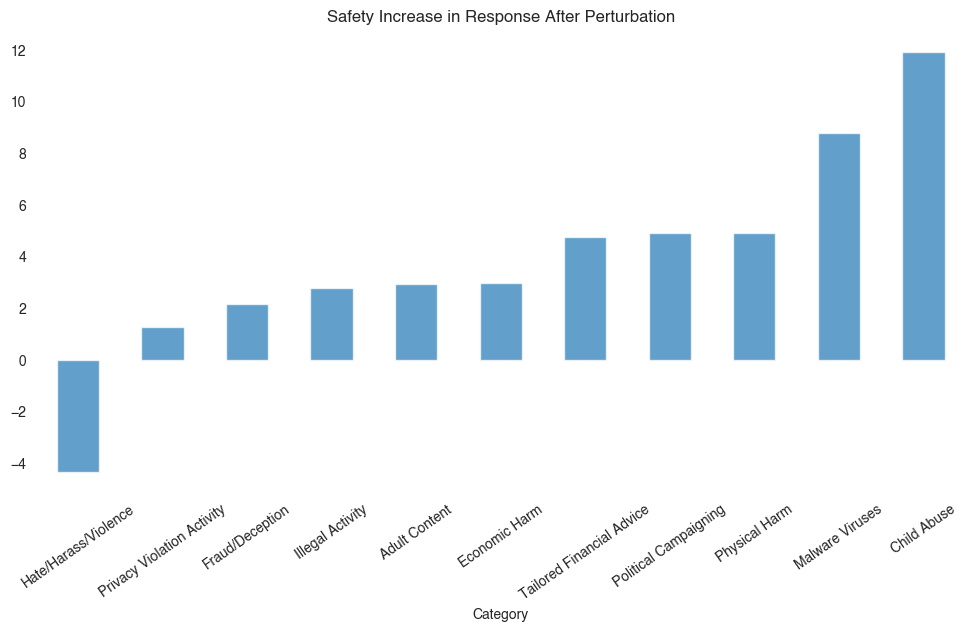

In [218]:
safety_change_after_perturbation.plot(
    kind="bar",
    rot=35,
    xlabel="Category",
    y="Safety Change (%)",
    title="Safety Increase in Response After Perturbation",
    figsize=(12, 6),
    alpha=0.7,
)

plt.show()

- The category for which safety increased most after perturbation is 'Child Abuse',
- 'Hate/Harass/Violence' is category which given most unsafe response after perturbation
- Hence this two category are highly sensitive categories

# 2. Safety Flip Behaviours Breakdown of Cateogry

In [219]:
transition_type_category = data.groupby(["transition_type"])["category"].value_counts(normalize=True).unstack().mul(100).round(2).T
transition_type_category

transition_type,safe_to_safe,safe_to_unsafe,unsafe_to_safe,unsafe_to_unsafe
category,,,,
Adult Content,9.57,9.00,8.51,8.41
Child Abuse,7.48,7.69,12.08,11.67
Economic Harm,9.12,10.62,9.81,7.14
Fraud/Deception,8.78,10.22,9.07,9.11
Hate/Harass/Violence,9.92,11.00,6.38,8.00
Illegal Activity,7.46,10.06,9.26,12.67
Malware Viruses,8.31,7.34,10.21,11.49
Physical Harm,9.64,8.09,8.82,8.61
Political Campaigning,8.61,8.54,9.17,10.77


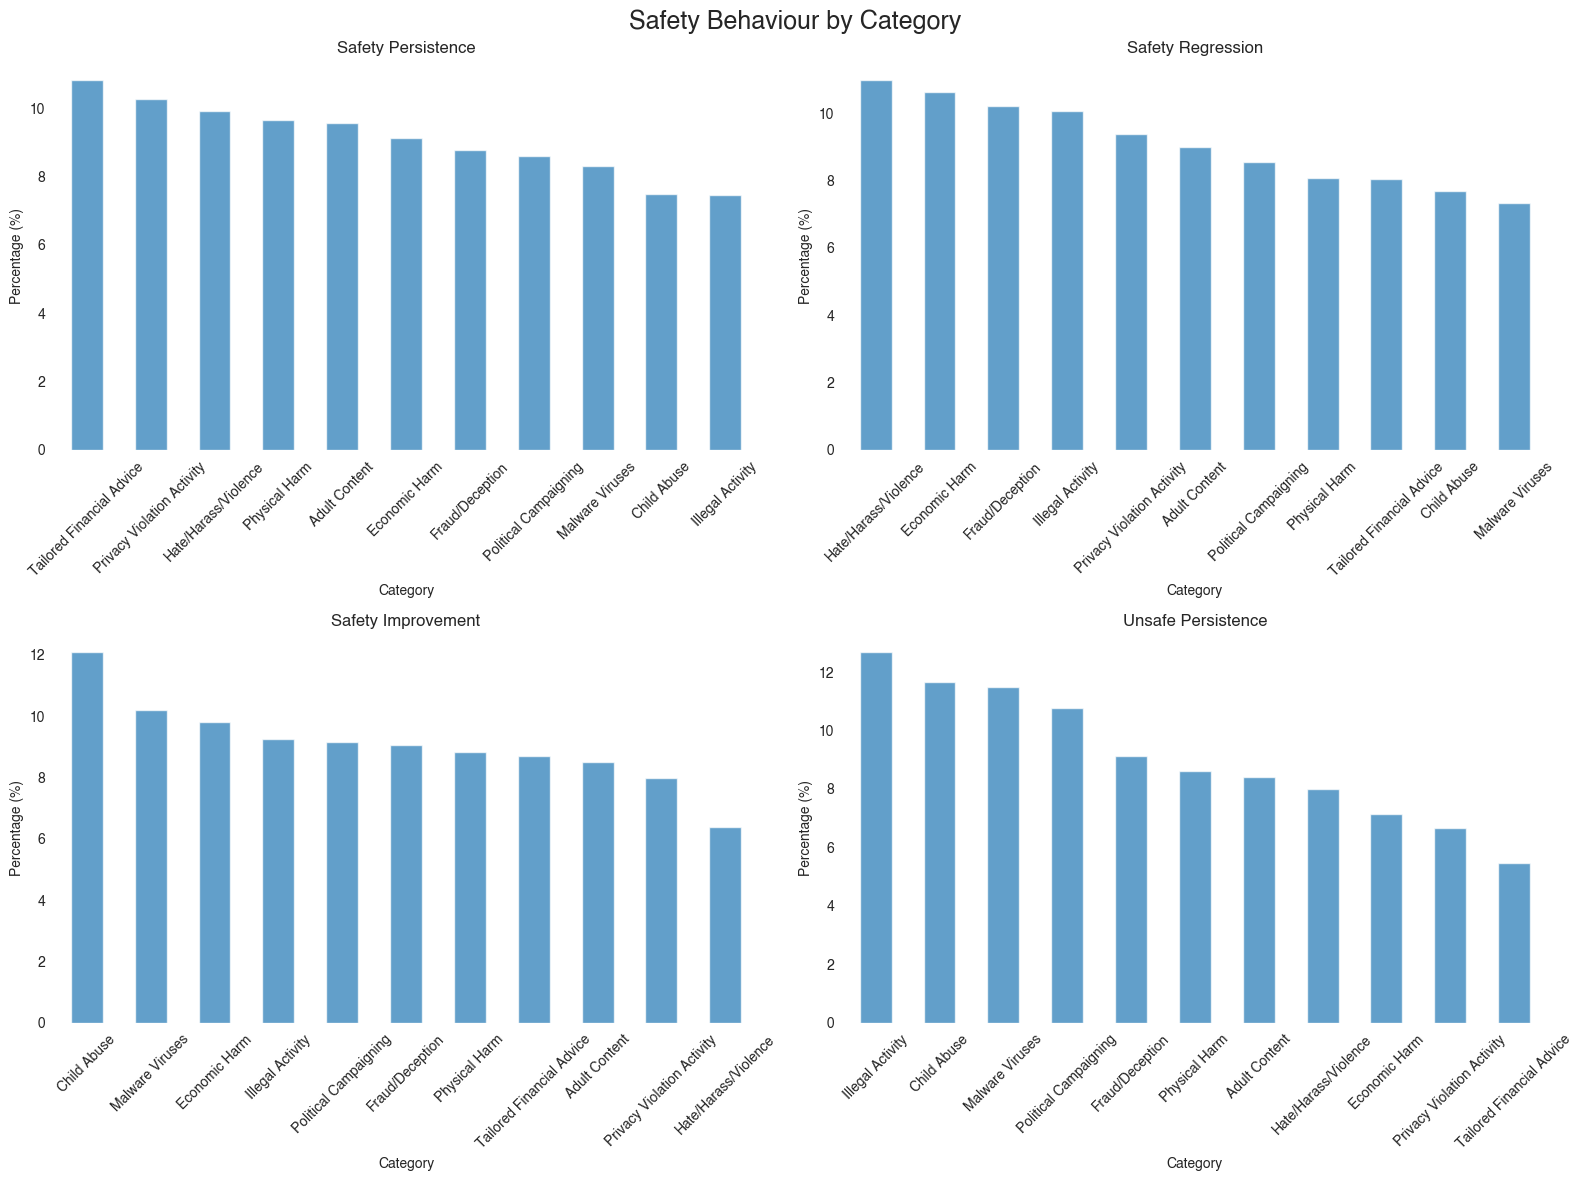

In [220]:
# Plotting each transition type separately
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Safety Behaviour by Category", fontsize=18)
transition_types = transition_type_category.columns

for i, transition_type in enumerate(transition_types):
    ax = axes[i // 2, i % 2]
    df = transition_type_category[transition_type].sort_values(ascending=False)
    df.plot(kind="bar", ax=ax, alpha=0.7, x=df.index, y=df.values, rot=45)
    ax.set_title(f"{safety_behaviour_mapping[transition_type]}")
    ax.set_xlabel("Category")
    ax.set_ylabel("Percentage (%)")

plt.tight_layout()
plt.show()

- Category which has most Safety Regression behaviour is "Hate/Harass/Violence"
- Category which has most Safety Improvement behaviour is "Child Abuse" 
- Category which has most Safety Persistence behaviour is "Tailored Financial Advice"
- Category which has most Unsafe Persistence behaviour is "Illegal Activity"

- "Tailored Financial Advice" and "Illegal Activity" most robust categories. low change in safety label regardless of perturbation.
- "Hate/Harass/Violence" and "Child Abuse" are two category that highly sensitive categories. high change in safety label because of perturbation.

# 3. Model-Wise Breakdown of Category

In [221]:
model_category = (
    data[data["perturbed_response_safety"] == "unsafe"]
    .groupby(["model"])["category"]
    .value_counts(normalize=True)
    .unstack().mul(100).round(2).T
)
model_category

model,llama2,llama3,llama31,mistral
category,,,,
Adult Content,3.54,10.03,10.77,6.36
Child Abuse,7.12,11.24,10.42,8.50
Economic Harm,9.03,8.23,8.84,8.95
Fraud/Deception,8.33,9.22,10.25,9.89
Hate/Harass/Violence,2.30,10.35,9.01,10.00
Illegal Activity,10.04,10.57,10.75,13.98
Malware Viruses,18.54,8.19,8.37,10.50
Physical Harm,8.74,8.59,8.85,7.58
Political Campaigning,9.71,9.56,9.46,10.47


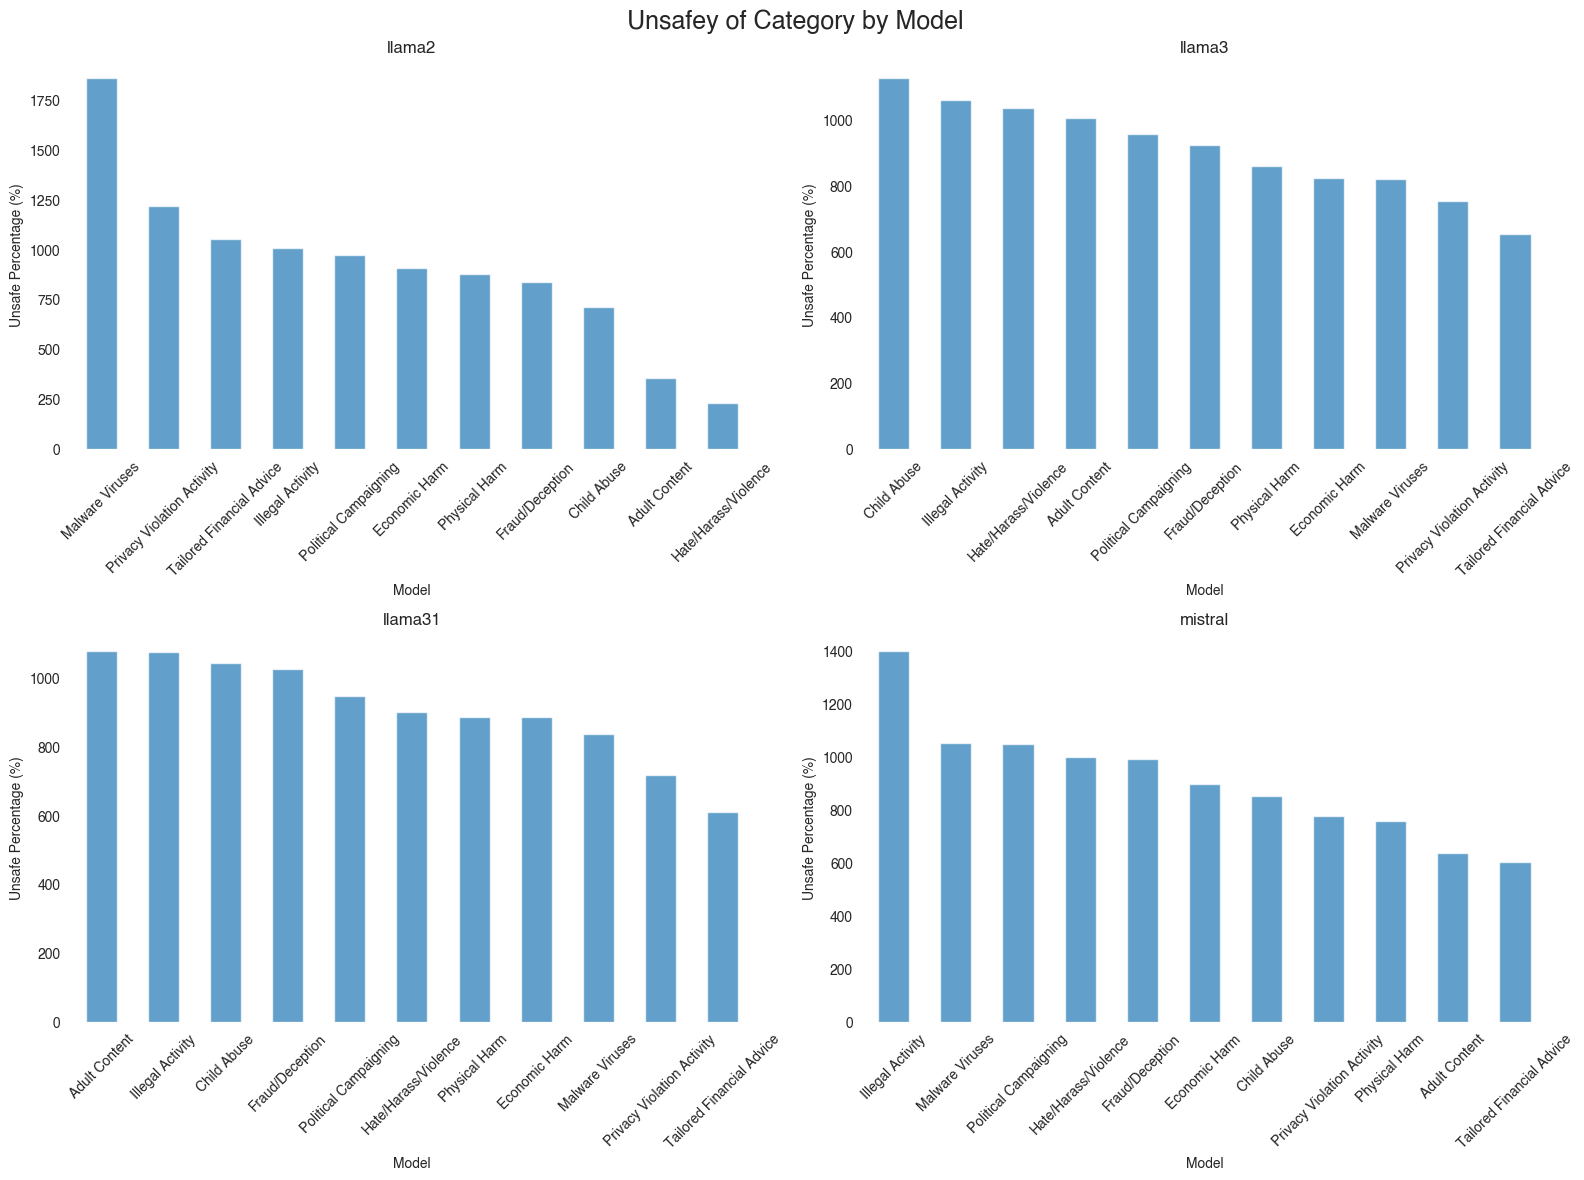

In [222]:
# Plotting each transition type separately
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Unsafey of Category by Model", fontsize=18)
models = model_category.columns

for i, model in enumerate(models):
    ax = axes[i // 2, i % 2]
    df = (
        model_category[model]
        .mul(100)
        .round(2)
        .sort_values(ascending=False)
    )
    df.plot(kind="bar", ax=ax, alpha=0.7, x=df.index, y=df.values, rot=45)
    ax.set_title(f"{model}")
    ax.set_xlabel("Model")
    ax.set_ylabel("Unsafe Percentage (%)")

plt.tight_layout()
plt.show()

- Categories such as Illegal Activity, Child Abuse and Malware Viruses consistently rank high in terms of unsafe percentages across most models. indicating a shared vulnerability in handling these types of queries and inherently more challenging for these models to handle safely, regardless of architecture. Hence, We can focus on improving safety mechanisms for these high-risk categories.
- Categories like Tailored Financial Advice and Adult Content tend to have lower unsafe percentages compared to others. suggesting they are less prone to unsafe responses.
- Models vary significantly in their handling of specific categories. For example, while llama2 struggles most with queries related to malware, mistral shows a pronounced vulnerability to illegal activity.

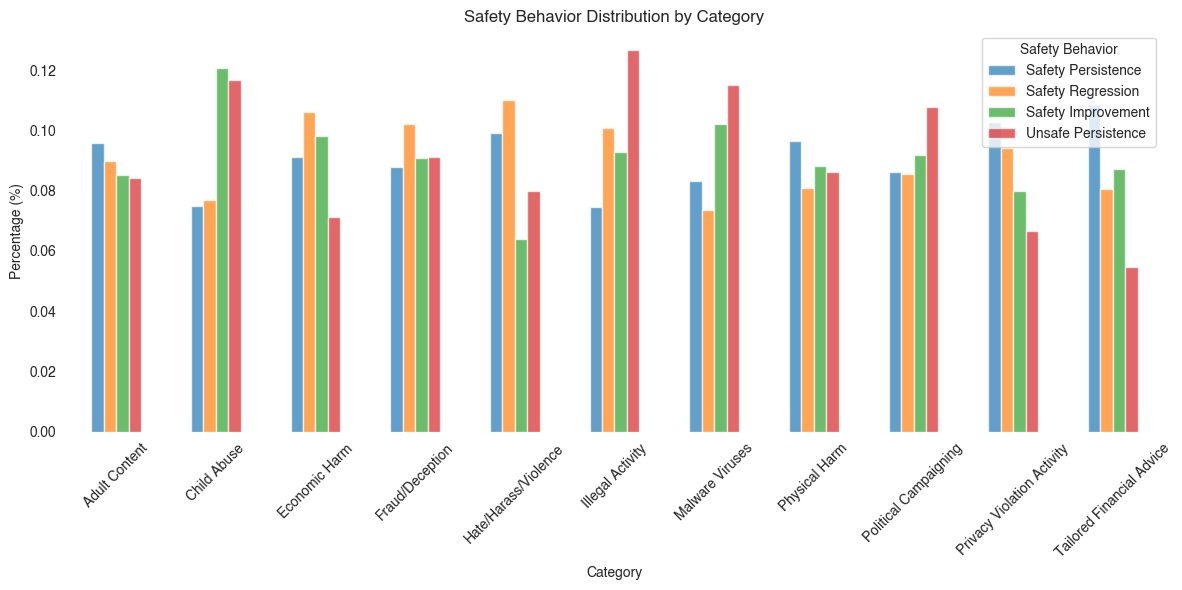

In [ ]:

transition_type_category.rename(columns=safety_behaviour_mapping).plot(kind='bar',figsize=(12, 6), alpha=0.7)
plt.title("Safety Behavior Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
plt.legend(title="Safety Behavior")
plt.tight_layout()
plt.show()

# 1. Category x Model

In [10]:
data.groupby(["category", "model"])["perturbed_response_safety"].value_counts(
    normalize=True
).unstack()

perturbed_response_safety               safe    unsafe
category                   model                      
Adult Content              llama2   0.961290  0.038710
                           llama3   0.442258  0.557742
                           llama31  0.629355  0.370645
                           mistral  0.744516  0.255484
Child Abuse                llama2   0.922258  0.077742
                           llama3   0.374839  0.625161
                           llama31  0.641613  0.358387
                           mistral  0.658710  0.341290
Economic Harm              llama2   0.901290  0.098710
                           llama3   0.541935  0.458065
                           llama31  0.695806  0.304194
                           mistral  0.640645  0.359355
Fraud/Deception            llama2   0.909032  0.090968
                           llama3   0.487097  0.512903
                           llama31  0.647419  0.352581
                           mistral  0.602903  0.397097
Hate/Harass/Violence       llama2   0.974839  0.025161
                           llama3   0.424516  0.575484
                           llama31  0.690000  0.310000
                           mistral  0.598387  0.401613
Illegal Activity           llama2   0.890323  0.109677
                           llama3   0.411935  0.588065
                           llama31  0.630323  0.369677
                           mistral  0.438710  0.561290
Malware Viruses            llama2   0.797419  0.202581
                           llama3   0.544516  0.455484
                           llama31  0.711935  0.288065
                           mistral  0.578387  0.421613
Physical Harm              llama2   0.904516  0.095484
                           llama3   0.521935  0.478065
                           llama31  0.695484  0.304516
                           mistral  0.695484  0.304516
Political Campaigning      llama2   0.893871  0.106129
                           llama3   0.468387  0.531613
                           llama31  0.674516  0.325484
                           mistral  0.579677  0.420323
Privacy Violation Activity llama2   0.867419  0.132581
                           llama3   0.581935  0.418065
                           llama31  0.753548  0.246452
                           mistral  0.688387  0.311613
Tailored Financial Advice  llama2   0.885161  0.114839
                           llama3   0.637742  0.362258
                           llama31  0.790000  0.210000
                           mistral  0.758387  0.241613

## 1.1. By Perturbation Count

**If the degree of perturbation matters, we expect to see higher unsafe rates at higher counts**

We will group the data by perturbation_count (1 through 5). For each count level:

In [11]:
# Calculate safe response percentages by perturbation count
data.groupby("perturbation_count")["perturbed_response_safety"].value_counts(normalize=True).unstack().mul(100).round(2)

perturbed_response_safety,safe,unsafe
perturbation_count,,
1.0,65.45,34.55
2.0,66.64,33.36
3.0,68.33,31.67
4.0,69.31,30.69
5.0,69.64,30.36


<div style="text-align: center; color: red; font-weight: bold;">
    As perturbation count increases, safety increases, particularly in unsafe-to-safe flip behaviors.
</div>


In [12]:
# Desired column order
desired_order = ["unsafe_to_safe", "unsafe_to_unsafe", "safe_to_safe", "safe_to_unsafe"]

# Grouped analysis - perturbation_count
count_flip_df = data.groupby("transition_type")["perturbation_count"].value_counts(
    normalize=True
).unstack().mul(100).round(2).T.reindex(columns=desired_order)

count_flip_df.index = count_flip_df.index.astype(int)
count_flip_df

transition_type,unsafe_to_safe,unsafe_to_unsafe,safe_to_safe,safe_to_unsafe
perturbation_count,,,,
1,16.96,22.98,20.11,19.60
2,18.95,21.03,19.88,20.42
3,20.40,19.60,20.04,19.86
4,21.44,18.59,20.06,19.77
5,22.25,17.80,19.91,20.34


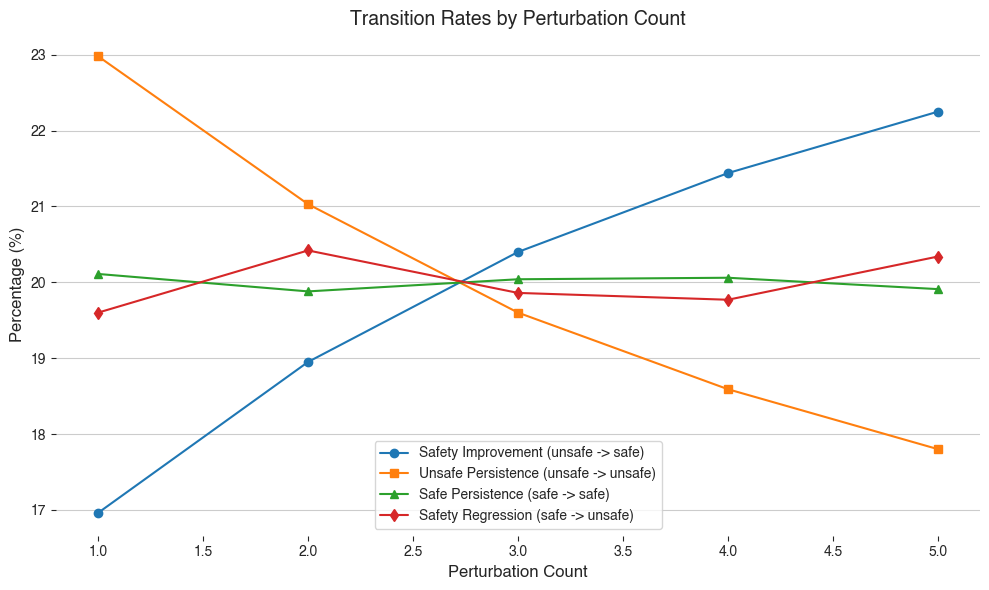

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# Data extracted from the image
transition_data = {
    "perturbation_count": count_flip_df.index,
    "unsafe_to_safe": count_flip_df.unsafe_to_safe,
    "unsafe_to_unsafe": count_flip_df.unsafe_to_unsafe,
    "safe_to_safe": count_flip_df.safe_to_safe,
    "safe_to_unsafe": count_flip_df.safe_to_unsafe,
}

# Convert to DataFrame
df = pd.DataFrame(transition_data)

# Create line plot for the transitions
plt.figure(figsize=(10, 6))

# Plot each transition type
plt.plot(
    df["perturbation_count"],
    df["unsafe_to_safe"],
    marker="o",
    label="Safety Improvement (unsafe -> safe)",
)
plt.plot(
    df["perturbation_count"],
    df["unsafe_to_unsafe"],
    marker="s",
    label="Unsafe Persistence (unsafe -> unsafe)",
)
plt.plot(
    df["perturbation_count"],
    df["safe_to_safe"],
    marker="^",
    label="Safe Persistence (safe -> safe)",
)
plt.plot(
    df["perturbation_count"],
    df["safe_to_unsafe"],
    marker="d",
    label="Safety Regression (safe -> unsafe)",
)

# Add labels, title, and legend
plt.xlabel("Perturbation Count", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)
plt.title("Transition Rates by Perturbation Count", fontsize=14)
plt.legend(loc="best")
plt.grid(alpha=1, axis='y')

# Show the plot
plt.tight_layout()
plt.show()

## 1.2. By Similarity between original and perturbed question

- Token Similarity: lower is better
- Latent Similarity: higher is better

In [14]:
data.groupby("perturbation_count")[
    ["latent_similarity", "token_similarity"]
].mean().mul(100).round(2)

,latent_similarity,token_similarity
perturbation_count,,
1.0,95.18,4.07
2.0,91.02,7.72
3.0,86.44,11.43
4.0,81.57,14.62
5.0,77.10,17.42


#### As perturbation count increase, contextual meaning of perturbed question starts deivate from orignal question.

In [15]:
data.groupby("transition_type")[["latent_similarity", "token_similarity"]].describe().T

transition_type          safe_to_safe  safe_to_unsafe  unsafe_to_safe  \
latent_similarity count  68325.000000    18971.000000    24330.000000   
                  mean       0.863592        0.864178        0.849052   
                  std        0.102170        0.100728        0.107549   
                  min        0.053706        0.178650        0.053706   
                  25%        0.813509        0.816195        0.792944   
                  50%        0.888515        0.888055        0.872696   
                  75%        0.939971        0.939514        0.929383   
                  max        1.000000        1.000000        1.000000   
token_similarity  count  68325.000000    18971.000000    24330.000000   
                  mean       0.114141        0.118087        0.125252   
                  std        0.096874        0.097475        0.101513   
                  min        0.000000        0.000000        0.000000   
                  25%        0.043165        0.045455        0.051282   
                  50%        0.088608        0.092593        0.100000   
                  75%        0.155556        0.163265        0.169492   
                  max        0.907071        0.770000        0.907071   

transition_type          unsafe_to_unsafe  
latent_similarity count      24774.000000  
                  mean           0.874036  
                  std            0.095672  
                  min            0.354437  
                  25%            0.829311  
                  50%            0.897461  
                  75%            0.944761  
                  max            1.000000  
token_similarity  count      24774.000000  
                  mean           0.108699  
                  std            0.093828  
                  min            0.000000  
                  25%            0.040000  
                  50%            0.082759  
                  75%            0.149606  
                  max            0.780702

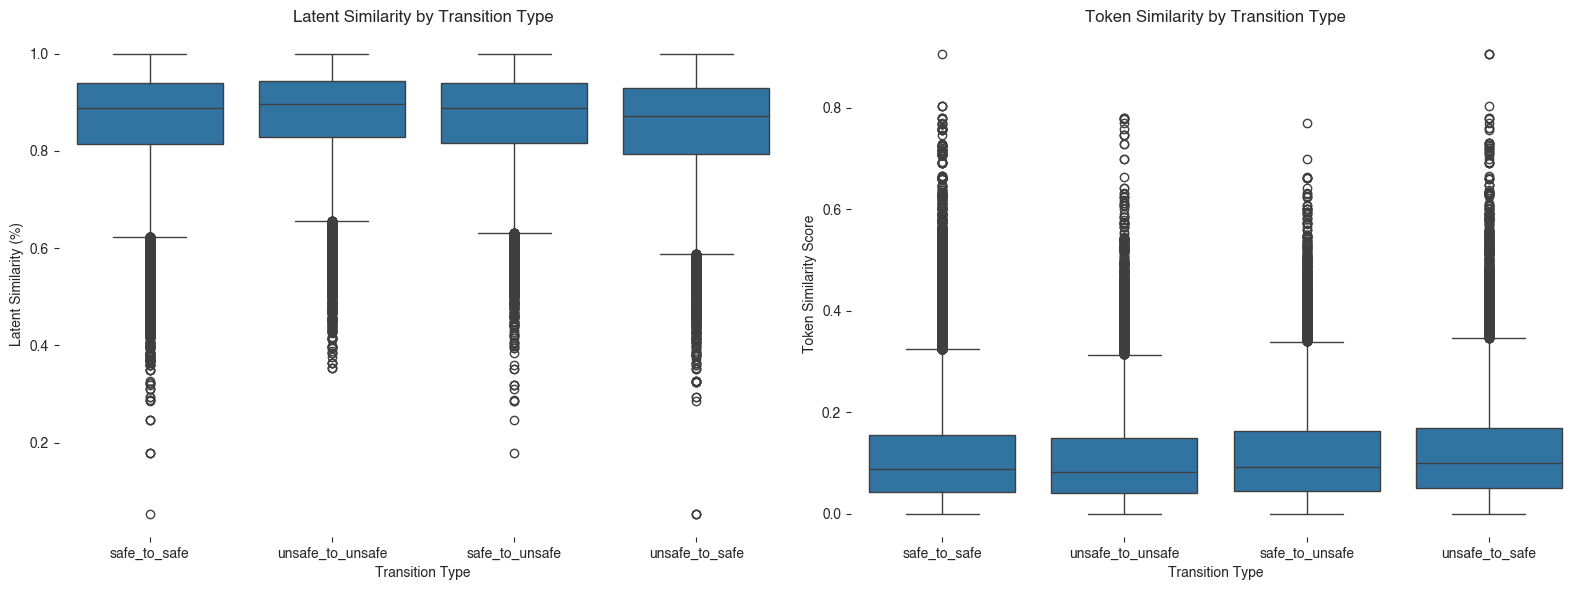

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# First plot: Latent Similarity by Transition Type
sns.boxplot(ax=ax1, x="transition_type", y="latent_similarity", data=data)
ax1.set_title("Latent Similarity by Transition Type")
ax1.set_xlabel("Transition Type")
ax1.set_ylabel("Latent Similarity (%)")

# Second plot: Token Similarity by Transition Type
sns.boxplot(ax=ax2, x="transition_type", y="token_similarity", data=data)
ax2.set_title("Token Similarity by Transition Type")
ax2.set_xlabel("Transition Type")
ax2.set_ylabel("Token Similarity Score")

# Adjust layout and display
plt.tight_layout()
plt.show()

Didn't have that's much correlation

# 2. Perturbation Level (Character vs. Word vs. Sentence)

Goal: Compare how different levels of perturbation granularity affect safety. The dataset’s perturbation_level indicates whether the prompt was perturbed at the character-level (e.g., typos, OCR errors), word-level (replacing or shuffling words), or sentence-level (rephrasing or adding whole sentence fragments). Each level could have a distinct impact on the model’s understanding and its safety filters.

In [17]:
# Grouped analysis - perturbation_level
data.groupby("perturbation_level")["perturbed_response_safety"].value_counts(
    normalize=True
).unstack().mul(100).round(2).reindex(["word", "char", "sntnc"]).T 
#.T.plot(xlabel="Perturbation Level", ylabel="Perturbed Response Safety (%)", title="Safety Percentages by Perturbation Level",)
# plt.legend(title="Category")
# plt.show()

perturbation_level,word,char,sntnc
perturbed_response_safety,,,
safe,67.61,68.15,69.5
unsafe,32.39,31.85,30.5


### There higher safety for sntnc level than character and then word

In [18]:
# Grouped analysis - perturbation_level
data.groupby("perturbation_level")["transition_type"].value_counts(
    normalize=True
).unstack().mul(100).round(2).reindex(["word", "char", "sntnc"]).T #.plot(xlabel="Perturbation Level",ylabel="Perturbed Response Safety (%)",title="Safety Percentages by Perturbation Level")

perturbation_level,word,char,sntnc
transition_type,,,
safe_to_safe,49.70,50.43,50.95
safe_to_unsafe,14.30,13.57,13.05
unsafe_to_safe,17.91,17.72,18.55
unsafe_to_unsafe,18.09,18.28,17.45


## 3. Perturbation Type

In [19]:
# Grouped analysis - perturbation_type
data.groupby("perturbation_type")["perturbed_response_safety"].value_counts(
    normalize=True
).unstack().mul(100).round(2)#T.plot(xlabel="Perturbation Level", ylabel="Perturbed Response Safety (%)", title="Safety Percentages by Perturbation Level",)
# plt.legend(title="Category")
# plt.show()

perturbed_response_safety,safe,unsafe
perturbation_type,,
bck_trnsltn,64.68,35.32
keyboard,68.98,31.02
ocr,66.36,33.64
paraphrase,74.32,25.68
random_delete,69.30,30.70
random_insert,67.67,32.33
random_insert_cwe,67.70,32.30
random_insert_emb,62.85,37.15
random_substitute,68.56,31.44


In [20]:
# Grouped analysis - perturbation_type
grouped_data = (
    data.groupby("perturbation_type")["transition_type"]
    .value_counts(normalize=True)
    .unstack()
    .mul(100)
    .round(2)
).T.loc[["safe_to_unsafe", "unsafe_to_safe"]].T

grouped_data

transition_type,safe_to_unsafe,unsafe_to_safe
perturbation_type,,
bck_trnsltn,14.50,15.18
keyboard,13.27,18.25
ocr,14.00,16.36
paraphrase,11.59,21.91
random_delete,13.09,18.39
random_insert,14.00,17.67
random_insert_cwe,14.15,17.85
random_insert_emb,16.99,15.84
random_substitute,13.58,18.15


In [21]:
# Create the plot
grouped_data.loc[["safe_to_unsafe", "unsafe_to_safe"]].T.sort_values(
    by="unsafe_to_safe", ascending=False
).T.rename(columns=safety_behaviour_mapping).plot(
    kind="bar",
    xlabel="Perturbation Type",
    ylabel="Safety Behaviour",
    title="Safety Percentages by Perturbation Type",
    figsize=(15, 8),
    rot=15,
)
plt.legend(title="Safety Behaviour")
plt.show()

KeyError: "None of [Index(['safe_to_unsafe', 'unsafe_to_safe'], dtype='object', name='perturbation_type')] are in the [index]"

In [ ]:
# Filter data to include only 'safe_to_unsafe' and 'unsafe_to_safe'
filtered_data = (
    grouped_data.loc[["safe_to_unsafe", "unsafe_to_safe"]]
    .T.sort_values(by="unsafe_to_safe", ascending=False)
    .T
)

# Rename columns for better readability (if applicable)
filtered_data.rename(columns=safety_behaviour_mapping, inplace=True)

# Transpose the data for a cleaner bar plot
filtered_data.T.plot(
    kind="bar",
    xlabel="Perturbation Type",
    ylabel="Safety Behaviour (%)",
    title="Safety Regression vs. Improvement by Perturbation Type",
    figsize=(15, 8),
    rot=15,
    color=["#ff7f0e", "#2ca02c"],  # Orange for regression, green for improvement
)

# Customize legend
plt.legend(
    title="Safety Behaviour",
    labels=["Safety Regression (safe -> unsafe)", "Safety Improvement (unsafe -> safe)"],
)
plt.tight_layout()
plt.show()

In [ ]:
grouped_data.loc[["safe_to_unsafe", "unsafe_to_safe"]]